In [23]:
### Import all necessary packages
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from wordcloud import WordCloud

### Data Cleaning

In [5]:
### Load the Dataset
df=pd.read_csv('amazonreviews.tsv',sep='\t')

In [7]:
### Data size
df.shape

(10000, 2)

In [8]:
### Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [9]:
### First five rows of data
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [10]:
### Check Duplicates
df.duplicated().sum()

np.int64(0)

    No Duplicates

In [12]:
### Check Missing values
df.isnull().sum()

label     0
review    0
dtype: int64

    No Missing values

### Exploratory Analysis

In [14]:
### Sentiment Distribution
df['label'].value_counts()

label
neg    5097
pos    4903
Name: count, dtype: int64

* The dataset contains 5,097 negative reviews and 4,903 positive reviews.
* The number of positive and negative reviews is almost equal.
* The dataset is well balanced, which is suitable for training a sentiment classification model.

In [15]:
#### Stopwords
stop= stopwords.words('english')
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [16]:
len(stop)

198

In [17]:
#### Lemmatization
lemma= WordNetLemmatizer()

In [18]:
def clean_text(text):
    text = text.lower()                              # Convert to lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)           # Remove special characters and numbers
    words = text.split()                             # Split into words

    words = [lemma.lemmatize(word) for word in words
             if word not in stop]                    # Remove stopwords and lemmatize

    return " ".join(words)

In [19]:
df['clean_review'] = df['review'].apply(clean_text)

In [20]:
df[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


* All reviews were converted to lowercase.
* Special characters and punctuation were removed.
* Common stopwords such as the, is, and, for were removed.
* Words were converted to their base form using lemmatization.
* The cleaned reviews are now ready for feature extraction and sentiment classification.

In [21]:
### Text for Positive Reviews
positive_text = " ".join(df[df['label'] == 'pos']['clean_review'])

In [22]:
### Generate Positive Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

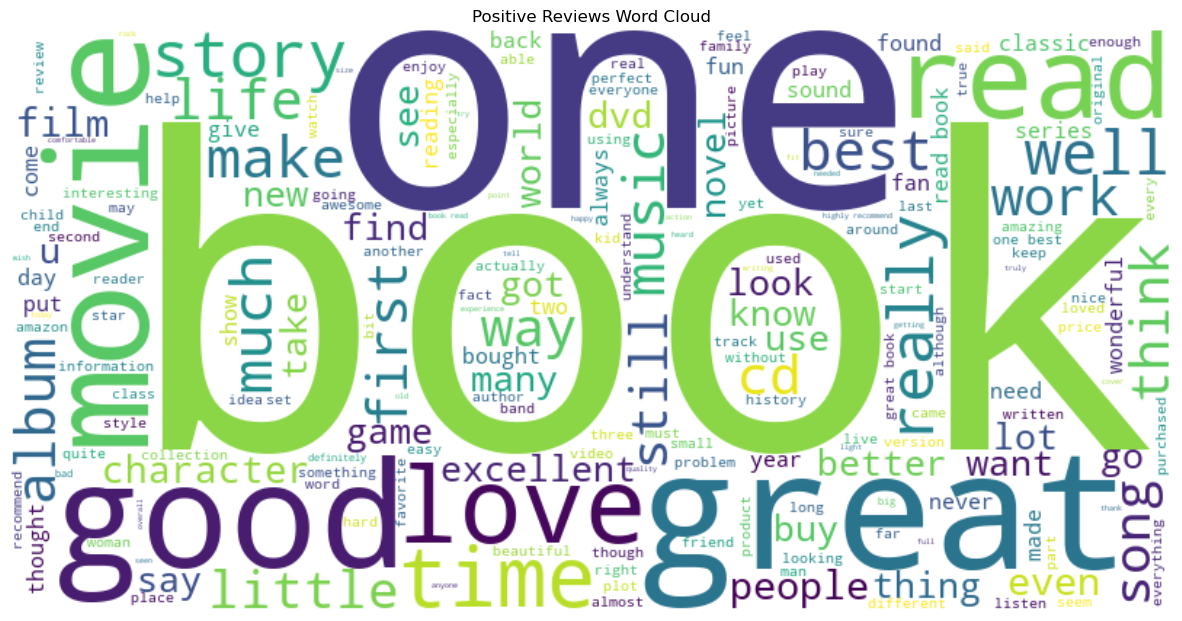

In [25]:
### Positive Word Cloud
plt.figure(figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

In [26]:
### Text for Negative Reviews
negative_text = " ".join(df[df['label'] == 'neg']['clean_review'])

In [27]:
### Generate Negative Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

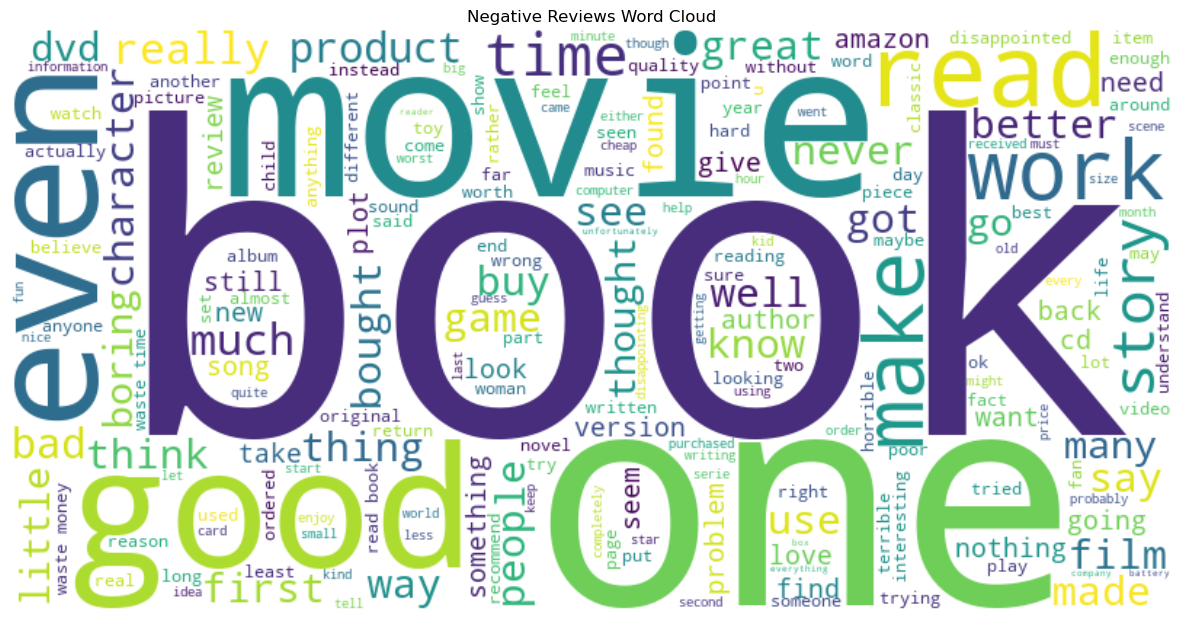

In [29]:
### Negative Word Cloud
plt.figure(figsize=(15,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

In [31]:
### Count Most Common Positive Words
from collections import Counter

positive_words = Counter(positive_text.split())
positive_words.most_common(20)

[('book', 3933),
 ('great', 2137),
 ('one', 1997),
 ('good', 1671),
 ('read', 1628),
 ('like', 1342),
 ('movie', 1330),
 ('time', 1189),
 ('love', 1045),
 ('would', 956),
 ('get', 948),
 ('well', 947),
 ('story', 875),
 ('really', 832),
 ('best', 813),
 ('first', 724),
 ('make', 711),
 ('year', 703),
 ('work', 701),
 ('much', 664)]

In [32]:
### Positive Words to DataFrame
positive_df = pd.DataFrame(
    positive_words.most_common(20),
    columns=['Word', 'Frequency']
)

positive_df

,Word,Frequency
0,book,3933
1,great,2137
2,one,1997
3,good,1671
4,read,1628
5,like,1342
6,movie,1330
7,time,1189
8,love,1045
9,would,956


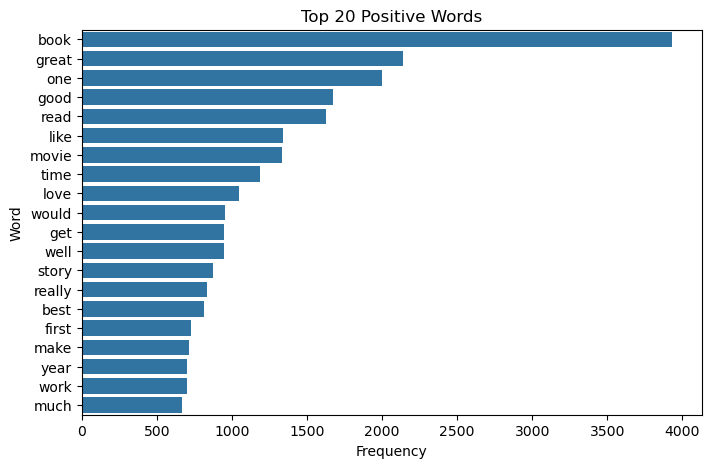

In [33]:
### Top 20 Positive Words
plt.figure(figsize=(8,5))
sns.barplot(data=positive_df, x='Frequency', y='Word')

plt.title("Top 20 Positive Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

* The word "book" appears most frequently in positive reviews.
* Words such as "great," "good," "love," and "best" are commonly used, showing that customers are satisfied with the products.
* Words like "read," "story," and "movie" suggest that many reviews are related to books and entertainment products.
* Overall, the positive reviews contain more appreciation and satisfaction-related words

In [34]:
### Count Most Common Negative Words
negative_words = Counter(negative_text.split())
negative_words.most_common(20)

[('book', 3760),
 ('one', 2193),
 ('movie', 1784),
 ('like', 1592),
 ('would', 1465),
 ('time', 1321),
 ('get', 1299),
 ('read', 1275),
 ('good', 1163),
 ('even', 910),
 ('buy', 842),
 ('really', 783),
 ('much', 782),
 ('work', 781),
 ('story', 781),
 ('make', 776),
 ('money', 767),
 ('bad', 764),
 ('first', 760),
 ('product', 707)]

In [35]:
### negative Words to DataFrame
negative_df = pd.DataFrame(
    negative_words.most_common(20),
    columns=['Word', 'Frequency']
)

negative_df

,Word,Frequency
0,book,3760
1,one,2193
2,movie,1784
3,like,1592
4,would,1465
5,time,1321
6,get,1299
7,read,1275
8,good,1163
9,even,910


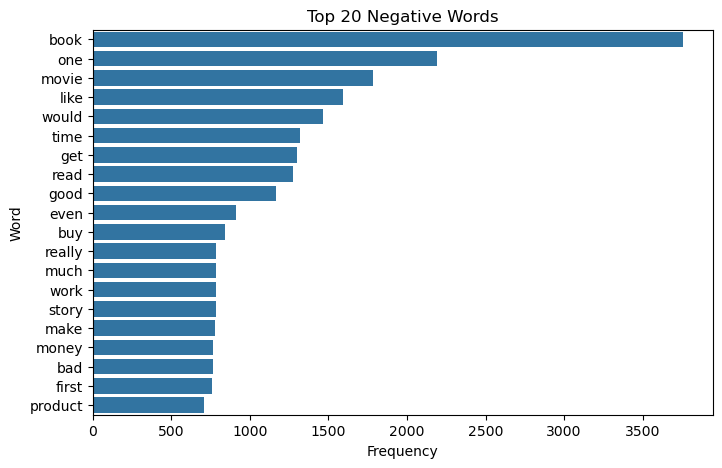

In [36]:
### Top 20 negative Words
plt.figure(figsize=(8,5))
sns.barplot(data=negative_df, x='Frequency', y='Word')

plt.title("Top 20 Negative Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

* The word "book" appears most frequently in negative reviews.
* Words such as "bad," "buy," "money," and "product" indicate customer dissatisfaction with the products.
* Words like "movie," "story," and "read" show that many negative reviews are related to books and entertainment products.
* Overall, the negative reviews mainly contain words related to complaints and unsatisfactory experiences.

In [37]:
### Reviews into TF-IDF Features
tfidf = TfidfVectorizer(max_features=5000)

feature = tfidf.fit_transform(df['clean_review'])
target = df['label']

In [39]:
### Split Dataset into Training and Testing 
x_train, x_test, y_train, y_test = train_test_split(feature,target,test_size=0.2,random_state=100,stratify=target)

print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 5000)
X_test : (2000, 5000)
y_train: (8000,)
y_test : (2000,)


* The cleaned reviews were converted into numerical features using the TF-IDF technique.
* The dataset was divided into 80% training data and 20% testing data.
* The training data will be used to train the model, and the testing data will be used to evaluate its performance.

In [41]:
# Train Logistic Regression Model
lr = LogisticRegression()

lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [42]:
# Predict on Test Data
y_pred = lr.predict(x_test)

In [43]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.865


In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         neg       0.86      0.87      0.87      1019
         pos       0.87      0.86      0.86       981

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.87      0.86      0.86      2000



In [47]:
svm = LinearSVC()

svm.fit(x_train,y_train)

svm_pred = svm.predict(x_test)

In [48]:
accuracy = accuracy_score(y_test, svm_pred)
print("Accuracy:", accuracy)

Accuracy: 0.854


In [50]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

         neg       0.86      0.85      0.86      1019
         pos       0.84      0.86      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [51]:
### 5-Fold Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr,feature,target,cv=5,scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.8575 0.8265 0.82   0.837  0.8525]
Mean Accuracy: 0.8387


* The model performed consistently across all five folds.
* The accuracy values are close to each other, indicating stable performance.
* The average cross-validation accuracy is 83.87%, showing that the model generalizes well to unseen data.

In [52]:
### Linear SVM
from sklearn.svm import LinearSVC

In [54]:
# Train Linear SVM Model
svm = LinearSVC()
svm.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [55]:
### Predict Test Data
svm_pred = svm.predict(x_test)

In [57]:
### Calculate Accuracy
svm_accuracy = accuracy_score(y_test, svm_pred)
print("Accuracy:", svm_accuracy)
print(classification_report(y_test, svm_pred))

Accuracy: 0.854
              precision    recall  f1-score   support

         neg       0.86      0.85      0.86      1019
         pos       0.84      0.86      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



* Both Logistic Regression and Linear SVM achieved the same accuracy of 85.4%.
* Both models showed similar F1-scores, indicating balanced classification performance.
* Since both models performed equally well, either model can be used for automated sentiment analysis.

**Conclusion**
* The customer review data was cleaned by removing duplicate records and preprocessing the review text using lowercasing, stopword removal, and lemmatization.
* Exploratory analysis included sentiment distribution, word clouds, and the most common positive and negative words.
* TF-IDF was used to convert the cleaned text into numerical features for machine learning.
* Logistic Regression and Linear SVM models were trained and evaluated using an 80:20 train-test split.
* Both models achieved an accuracy of 85.4% with an F1-score of approximately 0.85, demonstrating good performance in classifying customer reviews.
* The 5-fold cross-validation produced a mean accuracy of 83.87%, indicating that the model is stable and generalizes well to unseen data.
* The developed sentiment analysis system can automatically classify reviews as positive or negative, helping businesses monitor customer feedback, identify issues quickly, and improve customer satisfaction.